[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_03/TSA_ch3_unit_root_tests/TSA_ch3_unit_root_tests.ipynb)

# TSA_ch3_unit_root_tests

ADF, Phillips-Perron (written out with the Newey-West long-run variance) and KPSS tests on fourteen real series: Romanian GDP, HICP and inflation, US real GDP, EUR/RON, BET and S&P 500 log prices and returns, the Nile flow; the joint ADF-KPSS verdict; KPSS partial sums of a stationary AR(1) and of a random walk.

*Time Series Analysis (TSA), Chapter 3: Unit roots and ARIMA models. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_03/TSA_ch3_unit_root_tests


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # default size about 7 inches wide (as in MFM); a chart is shown 11-13 cm wide on a slide, so these font sizes
    # give 7-9 pt text there. Multi-panel charts should stay near 7-7.6 inches wide: at 10-11 inches the axis
    # text drops to about 5 pt on the slide.
    rc['figure.figsize'] = (7.0, 3.4)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [5]:
import itertools

import statsmodels.api as sm

from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss, zivot_andrews

from statsmodels.tsa.adfvalues import mackinnonp, mackinnoncrit

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.arima_process import ArmaProcess

from statsmodels.stats.diagnostic import acorr_ljungbox

SEED = 2026

GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')

HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')

GDP_START = '2000-01-01'

START = '2000-01-01'

BAND_COL = st.IDAred

CASES = {'n': 'no constant', 'c': 'constant', 'ct': 'constant and trend'}

def ro_gdp():
    """Romanian quarterly real GDP (Eurostat), seasonally and calendar adjusted, million EUR (2010 prices)."""
    return read_eurostat(*GDP_SA).rename('gdp')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def ro_inflation(start='2005-01-01'):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    return (100 * np.log(ro_hicp()).diff(12)).dropna().loc[start:].rename('infl')


def us_gdp():
    """US quarterly real GDP (FRED GDPC1, billions of chained 2017 dollars, seasonally adjusted)."""
    return read_fred('GDPC1').rename('us_gdp')


def quarterly(s):
    """A quarterly series with a PeriodIndex (for statsmodels ARIMA forecasts with dates)."""
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='Q')
    return s


def monthly(s):
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='M')
    return s


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def acf_bars(ax, r, T, color=st.MainBlue, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def adf_test(x, reg='c', autolag='AIC', maxlag=None):
    """Augmented Dickey-Fuller test: statistic, MacKinnon p-value, number of lags (chosen by AIC up to
    12 (T/100)^(1/4) by default), observations used, 5% critical value."""
    x = np.asarray(pd.Series(x).dropna(), float)
    r = adfuller(x, regression=reg, autolag=autolag, maxlag=maxlag)
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'nobs': int(r[3]), 'crit5': float(r[4]['5%']),
            'crit1': float(r[4]['1%']), 'crit10': float(r[4]['10%'])}


def pp_test(x, reg='c', lags=None):
    """Phillips-Perron Z_tau test: the Dickey-Fuller regression without lagged differences; the t-statistic is
    corrected with the Newey-West long-run variance of the residuals (Bartlett weights, 12 (T/100)^(1/4) lags).
    Same null hypothesis (unit root) and the same MacKinnon critical values as the ADF test."""
    y = np.asarray(pd.Series(x).dropna(), float)
    dy, ylag = np.diff(y), y[:-1]
    n = len(dy)
    cols = [ylag]
    if reg in ('c', 'ct'):
        cols.append(np.ones(n))
    if reg == 'ct':
        cols.append(np.arange(1, n + 1, dtype=float))
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, dy, rcond=None)
    u = dy - X @ beta
    k = X.shape[1]
    s2 = u @ u / (n - k)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[0, 0])
    t = beta[0] / se
    L = int(np.ceil(12 * (n / 100) ** 0.25)) if lags is None else lags
    g0 = u @ u / n
    lam2 = g0 + 2 * sum((1 - j / (L + 1)) * (u[j:] @ u[:-j]) / n for j in range(1, L + 1))
    z = np.sqrt(g0 / lam2) * t - 0.5 * (lam2 - g0) / np.sqrt(lam2) * n * se / np.sqrt(s2)
    return {'stat': float(z), 'p': float(mackinnonp(z, regression=reg, N=1)), 'lags': L,
            'crit5': float(mackinnoncrit(N=1, regression=reg, nobs=n)[1])}


def kpss_test(x, reg='c'):
    """KPSS test of stationarity (around a constant, reg='c', or a linear trend, reg='ct'); the p-value is
    interpolated from the table of Kwiatkowski et al. (1992) and lies between 0.01 and 0.10."""
    x = np.asarray(pd.Series(x).dropna(), float)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = kpss(x, regression=reg, nlags='auto')
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'crit5': float(r[3]['5%'])}


def za_test(x, reg='c'):
    """Zivot-Andrews test: unit root against stationarity with one break (in the level, reg='c'; in the trend,
    reg='t'; in both, reg='ct') at an unknown date chosen to give the most negative t-statistic."""
    s = pd.Series(x).dropna()
    r = zivot_andrews(np.asarray(s, float), regression=reg, autolag='AIC')
    return {'stat': float(r[0]), 'p': float(r[1]), 'crit5': float(r[2]['5%']), 'lags': int(r[3]),
            'break': str(s.index[int(r[4])])[:10]}


def verdict(adf, kp, alpha=0.05):
    """ADF and KPSS together: 'I(0)', 'I(1)', or 'conflict' (both reject) / 'inconclusive' (neither rejects)."""
    a, k = adf['p'] < alpha, kp['stat'] > kp['crit5']
    return {(True, False): 'I(0)', (False, True): 'I(1)', (True, True): 'conflict', (False, False): 'inconclusive'}[(a, k)]


def df_tau_batch(y, reg='c'):
    """Dickey-Fuller t-statistics (no lagged differences) for many paths at once: y has shape (R, T+1)."""
    y = np.asarray(y, float)
    dy, ylag = np.diff(y, axis=1), y[:, :-1]
    n = dy.shape[1]
    D = {'n': np.zeros((n, 0)), 'c': np.ones((n, 1)), 'ct': np.column_stack([np.ones(n), np.arange(1, n + 1)])}[reg]
    if D.shape[1]:
        P = D @ np.linalg.pinv(D)
        ylag = ylag - ylag @ P.T
        dy = dy - dy @ P.T
    sxx = np.sum(ylag ** 2, axis=1)
    g = np.sum(ylag * dy, axis=1) / sxx
    u = dy - g[:, None] * ylag
    s2 = np.sum(u ** 2, axis=1) / (n - 1 - D.shape[1])
    return g / np.sqrt(s2 / sxx)


def random_walks(R, T, rng, drift=0.0, phi=1.0, sigma=1.0):
    """R paths of y_t = drift + phi y_{t-1} + e_t, y_0 = 0, t = 1..T (returned with y_0: shape (R, T+1))."""
    e = rng.normal(0, sigma, (R, T))
    y = np.zeros((R, T + 1))
    if phi == 1.0:
        y[:, 1:] = np.cumsum(drift + e, axis=1)
    else:
        for t in range(1, T + 1):
            y[:, t] = drift + phi * y[:, t - 1] + e[:, t - 1]
    return y


def ljung_box(x, m=10, df=0):
    """Ljung-Box Q*(m) with chi-square(m - df) p-value (df = number of estimated ARMA coefficients)."""
    t = acorr_ljungbox(np.asarray(pd.Series(x).dropna(), float), lags=[m], model_df=df, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'm': m, 'df': m - df}


def fig_kpss_sums(T=250, save_it=True):
    """KPSS: partial sums S_t of the demeaned series, for a stationary AR(1) (phi = 0.5) and for a random walk."""
    rng = np.random.default_rng(SEED + 6)
    e = rng.normal(size=T)
    ar = np.zeros(T)
    for t in range(1, T):
        ar[t] = 0.5 * ar[t - 1] + e[t]
    rw = np.cumsum(rng.normal(size=T))
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.1))
    out = {}
    for x, c, lab in [(ar, st.MainBlue, 'stationary AR(1), phi = 0.5'), (rw, st.IDAred, 'random walk')]:
        S = np.cumsum(x - x.mean())
        k = kpss_test(x, 'c')
        ax[0].plot(x - x.mean(), color=c, lw=0.9, label=lab)
        ax[1].plot(S, color=c, lw=1.2, label='_nolegend_')
        out['ar' if c == st.MainBlue else 'rw'] = k
    ax[0].set_title('Demeaned series $e_t = y_t - \\bar y$')
    ax[1].set_title('Partial sums $S_t = e_1 + \\dots + e_t$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    for a in ax:
        a.set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_kpss_sums', save_it)
    return out


def real_series():
    """The series of the unit-root table, with the deterministic terms of the test (ADF, PP, KPSS)."""
    g = 100 * np.log(ro_gdp().loc[GDP_START:])
    h = 100 * np.log(ro_hicp().loc['2005-01-01':])
    pi = ro_inflation()
    fx = 100 * np.log(load_close('eurron'))
    bet = 100 * np.log(load_close('bet', start=START))
    sp = 100 * np.log(load_close('sp500', start=START))
    us = 100 * np.log(us_gdp())
    nile = load_statsmodels('nile')
    return [('Romania real GDP, log', g, 'ct'), ('Romania real GDP, growth', g.diff(), 'c'),
            ('Romania HICP, log', h, 'ct'), ('Romania inflation, 12 months', pi, 'c'),
            ('Romania inflation, change', pi.diff(), 'c'),
            ('EUR/RON, log', fx, 'c'), ('EUR/RON, returns', fx.diff(), 'c'),
            ('BET, log price', bet, 'ct'), ('BET, returns', bet.diff(), 'c'),
            ('S&P 500, log price', sp, 'ct'), ('S&P 500, returns', sp.diff(), 'c'),
            ('US real GDP, log', us, 'ct'), ('US real GDP, growth', us.diff(), 'c'),
            ('Nile flow', nile, 'c')]


def unit_root_table():
    """ADF, PP and KPSS on the series of real_series(); saved as ch3_unit_root_tests.csv."""
    rows = {}
    for name, x, reg in real_series():
        x = x.dropna()
        a, p, k = adf_test(x, reg), pp_test(x, reg), kpss_test(x, reg)
        rows[name] = {'reg': reg, 'n': int(len(x)), 'adf': a, 'pp': p, 'kpss': k, 'verdict': verdict(a, k)}
    pd.DataFrame({k: {'deterministic': v['reg'], 'T': v['n'], 'ADF': v['adf']['stat'], 'ADF p': v['adf']['p'],
                      'ADF lags': v['adf']['lags'], 'PP': v['pp']['stat'], 'PP p': v['pp']['p'], 'KPSS': v['kpss']['stat'],
                      'KPSS 5% cv': v['kpss']['crit5'], 'ADF+KPSS': v['verdict']} for k, v in rows.items()}).T.to_csv(
        os.path.join(globals().get('OUT_DIR', globals().get('HERE', '.')), 'ch3_unit_root_tests.csv'), float_format='%.4f')
    return rows

## Run

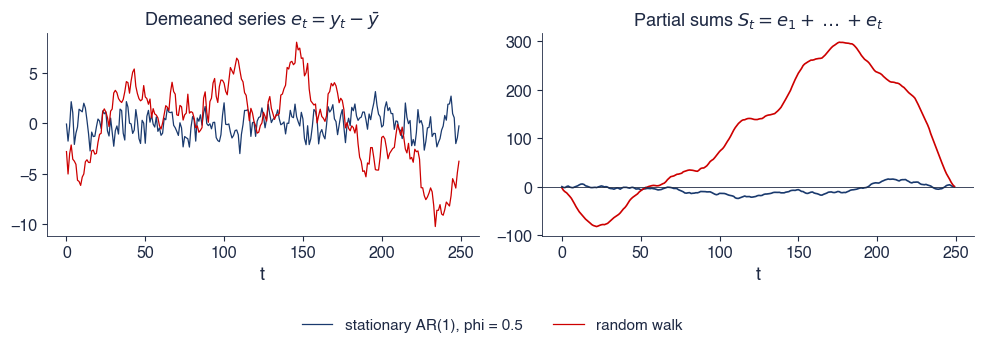

{'ar': {'stat': 0.15926294256350107, 'p': 0.1, 'lags': 6, 'crit5': 0.463}, 'rw': {'stat': 0.733401198247466, 'p': 0.010508981977503093, 'lags': 10, 'crit5': 0.463}}


                                    ADF     ADF p         PP       KPSS  \
Romania real GDP, log         -2.311535  0.427581  -2.192991   0.197924   
Romania real GDP, growth     -10.769545       0.0 -10.878365   0.263065   
Romania HICP, log             -0.961364  0.949096  -0.883651   0.314494   
Romania inflation, 12 months  -1.935718  0.315449  -2.309199   0.404027   
Romania inflation, change     -4.825128  0.000049 -11.313515   0.105162   
EUR/RON, log                  -1.222734   0.66374  -1.151568  10.255245   
EUR/RON, returns             -27.424478       0.0 -60.823214   0.055252   
BET, log price                -1.903364  0.652924  -2.348332   1.142908   
BET, returns                 -16.503303       0.0 -74.550721   0.359518   
S&P 500, log price            -2.081369  0.556513  -2.364688   2.281017   
S&P 500, returns             -14.264229       0.0 -91.414598   0.448668   
US real GDP, log              -1.537176  0.816065  -1.198337   0.581238   
US real GDP, growth      

In [6]:
print(fig_kpss_sums())
U = unit_root_table()
print(pd.DataFrame({k: {"ADF": v["adf"]["stat"], "ADF p": v["adf"]["p"], "PP": v["pp"]["stat"], "KPSS": v["kpss"]["stat"], "verdict": v["verdict"]} for k, v in U.items()}).T)

![tsa_ch3_kpss_sums](./tsa_ch3_kpss_sums.png)

Output: `tsa_ch3_kpss_sums.pdf`